In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # libraries required

In [8]:
# load the dataset
df = pd.read_excel('/content/ABC Company.xlsx')

print('Shape of dataset :', df.shape)
print('\nColumn names :', df.columns.tolist())
print('\nFirst 5 rows :')
df.head()

Shape of dataset : (458, 9)

Column names : ['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight', 'College', 'Salary']

First 5 rows :


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [9]:
# check basic info and missing values
print('Dataset Info :')
print(df.info())
print('\nMissing values :')
print(df.isnull().sum())

Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB
None

Missing values :
Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64


In [10]:
# replacing height column with random numbers between 150 and 180
np.random.seed(42)
df['Height'] = np.random.randint(150, 181, size=len(df))

print('Height column after replacement :')
print(df['Height'].describe())
print('\nMin height :', df['Height'].min())
print('Max height :', df['Height'].max())

Height column after replacement :
count    458.000000
mean     165.085153
std        9.412232
min      150.000000
25%      156.250000
50%      165.000000
75%      174.000000
max      180.000000
Name: Height, dtype: float64

Min height : 150
Max height : 180


In [11]:
# checking for missing values and fixing themn
print('Missing values before cleaning :')
print(df.isnull().sum())

# drop rows where salary or age is missing
df = df.dropna(subset=['Salary', 'Age'])

print('\nMissing values after cleaning :')
print(df.isnull().sum())
print('\nDataset shape after cleaning :', df.shape)

Missing values before cleaning :
Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

Missing values after cleaning :
Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     82
Salary       0
dtype: int64

Dataset shape after cleaning : (447, 9)


In [12]:
# count employees per team
team_count = df['Team'].value_counts()
team_percent = (team_count / len(df) * 100).round(2)

team_summary = pd.DataFrame({'Count': team_count, 'Percentage': team_percent})
print('Employee distribution across teams :')
print(team_summary)

Employee distribution across teams :
                        Count  Percentage
Team                                     
New Orleans Pelicans       19        4.25
New York Knicks            16        3.58
Milwaukee Bucks            16        3.58
Utah Jazz                  16        3.58
Golden State Warriors      15        3.36
Brooklyn Nets              15        3.36
Chicago Bulls              15        3.36
Detroit Pistons            15        3.36
Phoenix Suns               15        3.36
Sacramento Kings           15        3.36
Indiana Pacers             15        3.36
Toronto Raptors            15        3.36
Los Angeles Lakers         15        3.36
Los Angeles Clippers       15        3.36
Oklahoma City Thunder      15        3.36
Washington Wizards         15        3.36
Portland Trail Blazers     15        3.36
Houston Rockets            15        3.36
Atlanta Hawks              15        3.36
San Antonio Spurs          15        3.36
Charlotte Hornets          15        3.

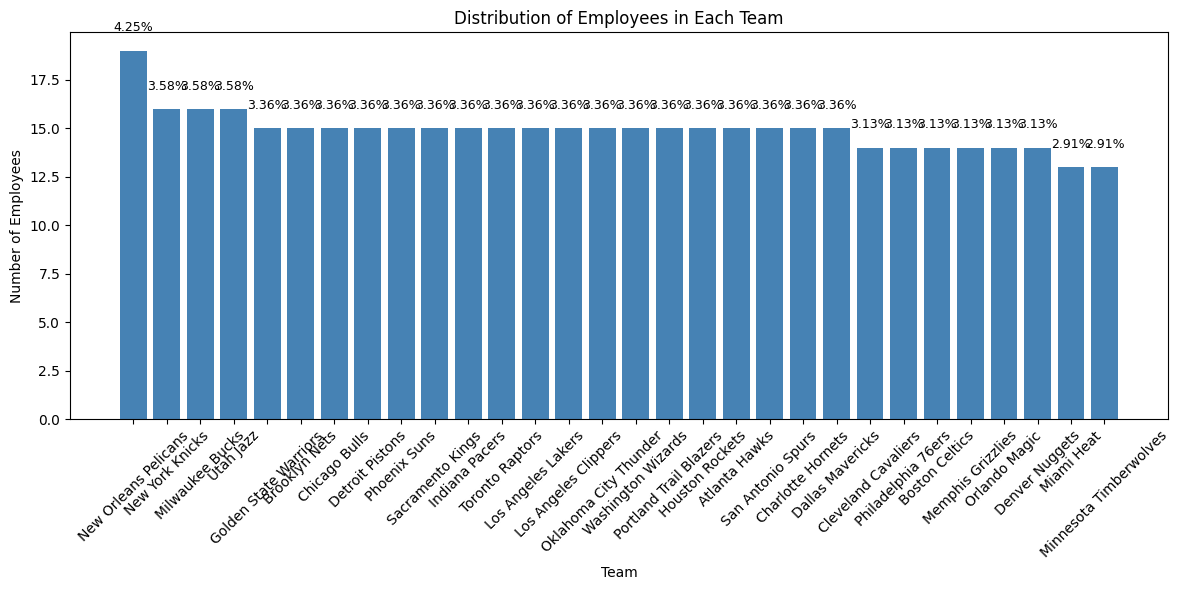

In [13]:
# bar chart for team distribution
plt.figure(figsize=(12, 6))
bars = plt.bar(team_count.index, team_count.values, color='steelblue')

# adding percentage labels on top of each bar
for bar, percent in zip(bars, team_percent.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             str(percent) + '%',
             ha='center', fontsize=9)

plt.title('Distribution of Employees in Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Observation:
# The New Orleans Pelicans and Memphis Grizzlies have the highest number of employees.
# Most teams have a fairly even distribution, ranging between 1% to 4% of total employees.
# No single team dominates with an unusually large share of employees.

In [14]:
# count employees per position
position_count = df['Position'].value_counts()
print('Employees by Position :')
print(position_count)

Employees by Position :
Position
SG    99
PF    97
PG    88
SF    84
C     79
Name: count, dtype: int64


/tmp/ipykernel_13434/2416162647.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Position', order=position_count.index, palette='Set2')


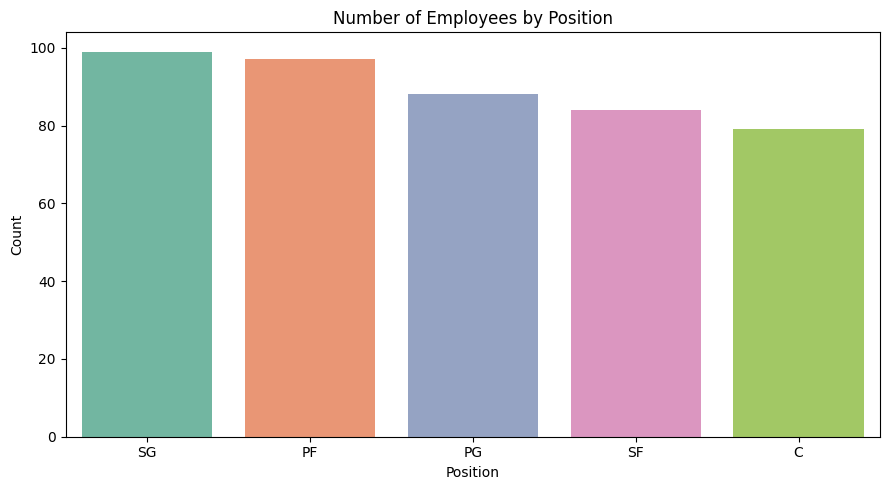

In [15]:
# bar chart for position distribution
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Position', order=position_count.index, palette='Set2')
plt.title('Number of Employees by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Observation:
# The SG (Shooting Guard) and PF (Power Forward) positions have the highest number of employees.
# The C (Center) position has the fewest employees across the company.
# The distribution across positions is fairly balanced with small differences.

In [16]:
# create age groups
bins = [18, 24, 29, 34, 39, 50]
labels = ['18-24', '25-29', '30-34', '35-39', '40+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

age_group_count = df['Age Group'].value_counts().sort_index()
print('Employees by Age Group :')
print(age_group_count)

Employees by Age Group :
Age Group
18-24    150
25-29    178
30-34     89
35-39     27
40+        3
Name: count, dtype: int64


/tmp/ipykernel_13434/2172903503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_count.index, y=age_group_count.values, palette='Oranges')


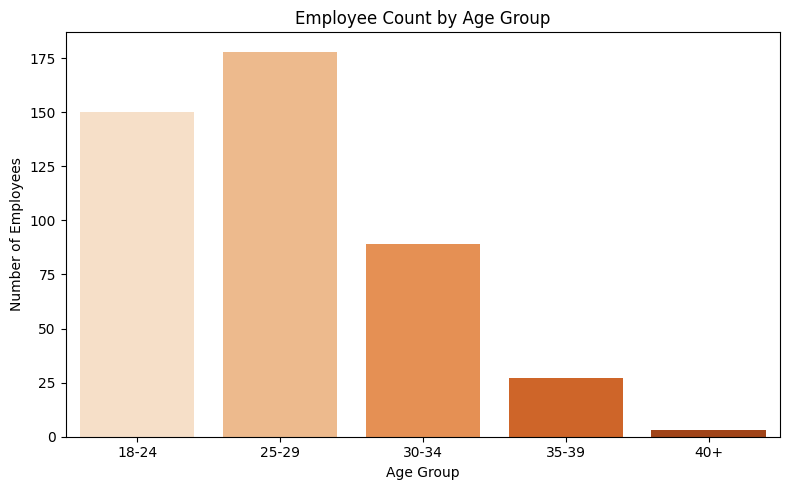

In [17]:
# bar chart for age group distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=age_group_count.index, y=age_group_count.values, palette='Oranges')
plt.title('Employee Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

# Observation:
# The 25-29 age group is the most common, making it the predominant age group in the company.
# Younger employees (18-24) and older employees (40+) are comparatively fewer.
# The workforce is mostly young to mid-career professionals.

In [18]:
# total salary by team
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
print('Top 5 teams by salary expenditure :')
print(team_salary.head())

print('\nTop team with highest salary :', team_salary.idxmax())
print('Total salary :', team_salary.max())

# total salary by position
position_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
print('\nSalary by position :')
print(position_salary)
print('\nTop position with highest salary :', position_salary.idxmax())

Top 5 teams by salary expenditure :
Team
Cleveland Cavaliers      106988689.0
Los Angeles Clippers      94854640.0
Oklahoma City Thunder     93765298.0
Golden State Warriors     88868997.0
Chicago Bulls             86783378.0
Name: Salary, dtype: float64

Top team with highest salary : Cleveland Cavaliers
Total salary : 106988689.0

Salary by position :
Position
C     466377332.0
PG    446848971.0
PF    442560850.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64

Top position with highest salary : C


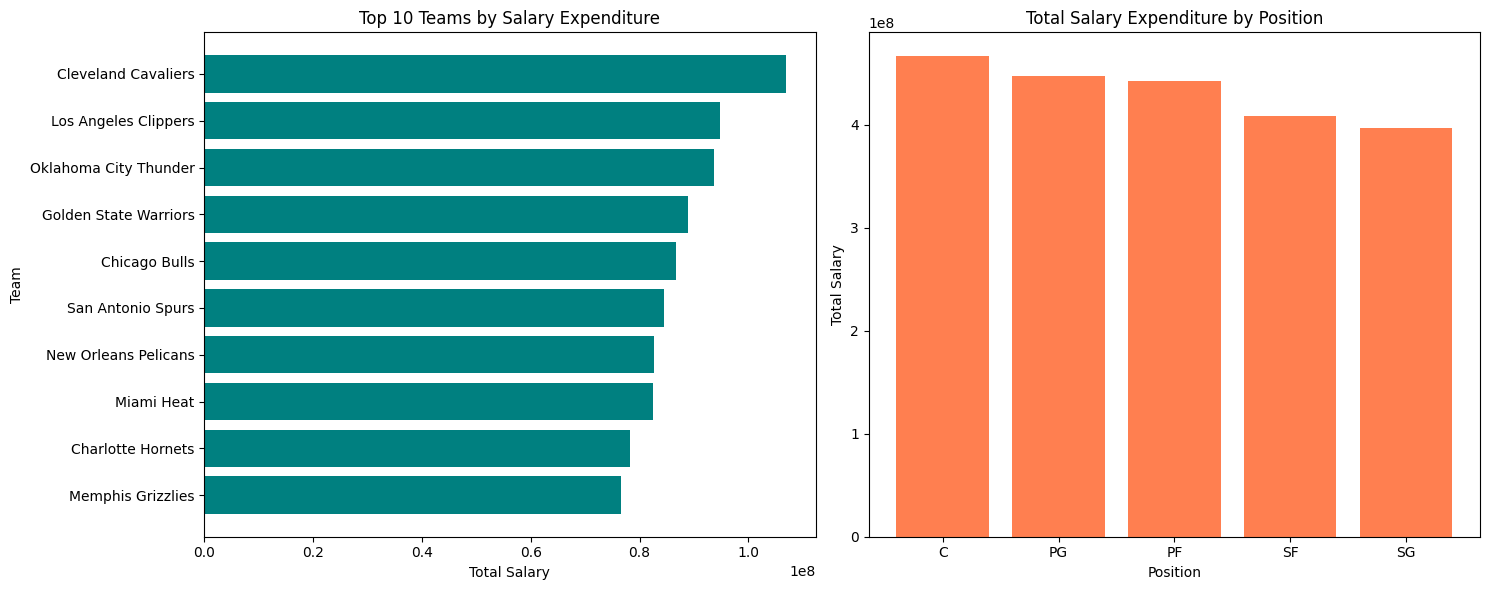

In [19]:
# bar charts for team and position salary
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# team salary chart
axes[0].barh(team_salary.index[:10], team_salary.values[:10], color='teal')
axes[0].set_title('Top 10 Teams by Salary Expenditure')
axes[0].set_xlabel('Total Salary')
axes[0].set_ylabel('Team')
axes[0].invert_yaxis()

# position salary chart
axes[1].bar(position_salary.index, position_salary.values, color='coral')
axes[1].set_title('Total Salary Expenditure by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Total Salary')

plt.tight_layout()
plt.show()

In [20]:
# correlation between age and salary
correlation = df['Age'].corr(df['Salary'])
print('Correlation between Age and Salary :', round(correlation, 4))

Correlation between Age and Salary : 0.214


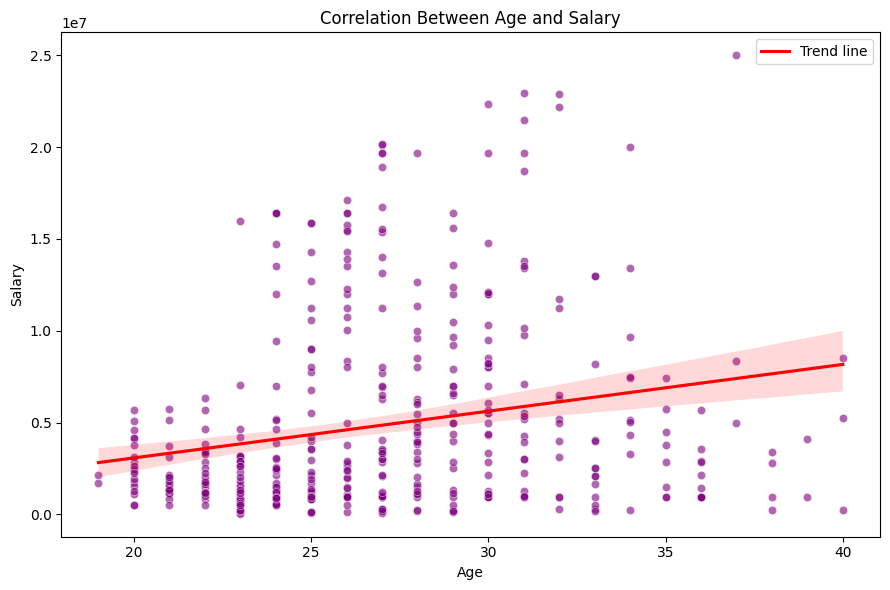

In [21]:
# scatter plot for age vs salary
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Age', y='Salary', color='purple', alpha=0.6)
sns.regplot(data=df, x='Age', y='Salary', scatter=False, color='red', label='Trend line')

plt.title('Correlation Between Age and Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

# Observation:
# There is a weak positive correlation between age and salary.
# Salary does not strictly increase with age - many younger employees also earn high salaries.
# The wide spread of salary values at each age indicates that age alone does not determine salary.